# 02 — Feature Engineering

Exploratory analysis of synthetic behavioral dataset.
Goal: understand distributions, correlations, and confounds before training.

In [1]:
import sys
from pathlib import Path

repo_root = Path(".").resolve().parent
sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk_classifier import FEATURE_COLS, DEMOGRAPHIC_COLS, TARGET_COL

df = pd.read_csv(repo_root / "data" / "synthetic" / "student_wellbeing.csv")
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(f"Label prevalence: {df[TARGET_COL].mean():.4f}")
df.head(3)

Loaded 30,000 rows, 14 columns
Label prevalence: 0.1796


,gender,race_ethnicity,first_gen,international_student,financial_aid_status,engagement_variance,sleep_schedule_drift,social_activity_decline,academic_trend,missed_class_streak,financial_stress_flag,help_seeking_flag,self_report_score,support_recommended
0,male,white,1,0,pell_grant,0.4305,0.1500,-0.2223,-0.3431,2,1,0,61.31,1
1,female,white,1,0,pell_grant,0.3441,0.3395,-0.3248,-0.2576,4,1,0,77.29,1
2,male,pacific_islander,1,0,both,0.3096,0.3994,-0.4201,-0.4223,3,0,0,63.90,1


## 1. Feature Distributions by Label

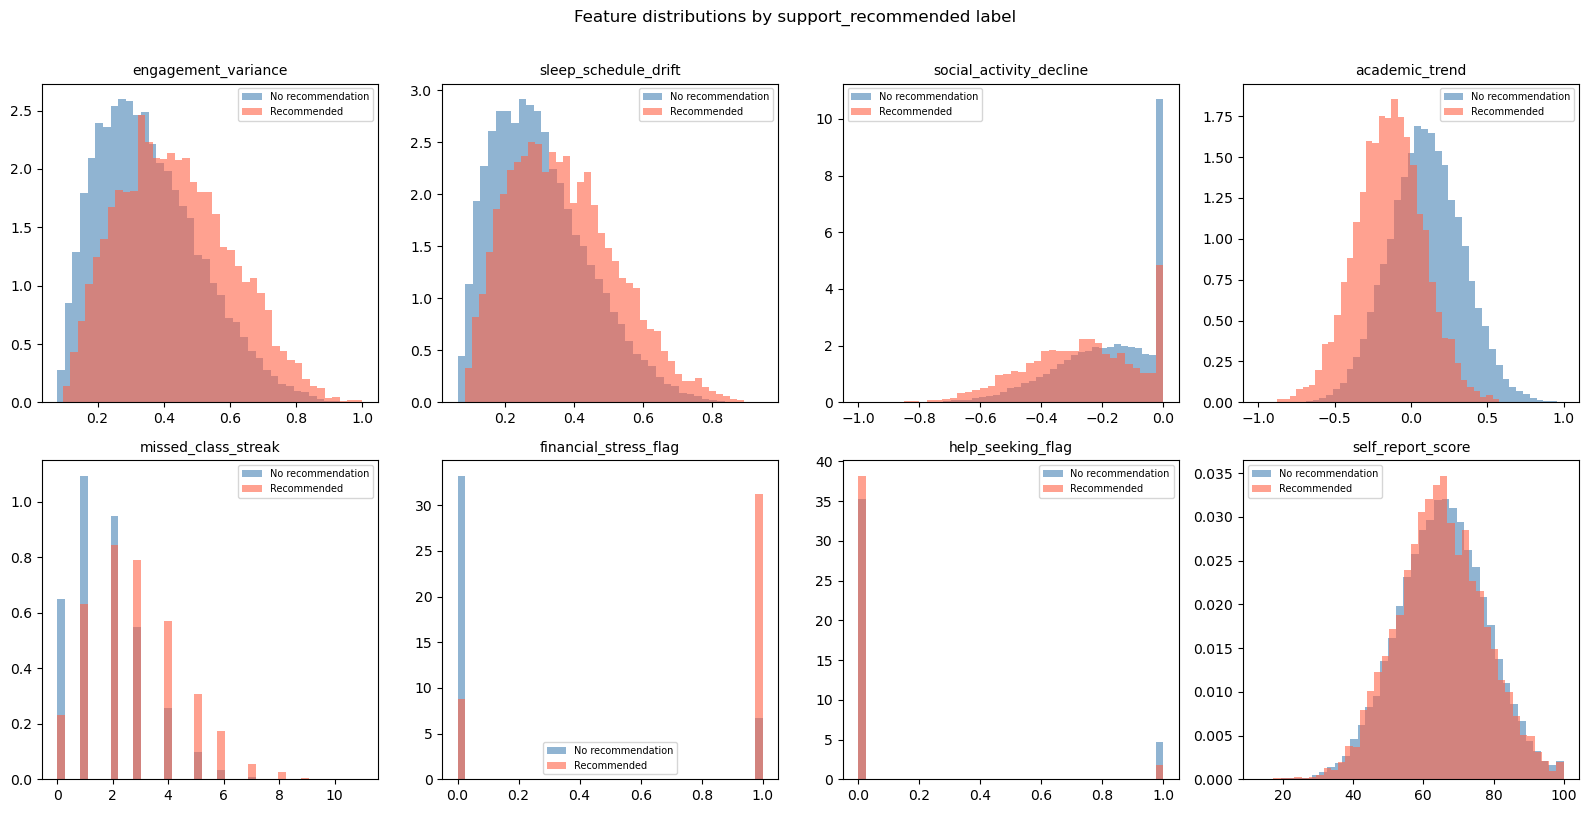

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for label, color, name in [(0, "steelblue", "No recommendation"), (1, "tomato", "Recommended")]:
        subset = df[df[TARGET_COL] == label][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel("")

plt.suptitle("Feature distributions by support_recommended label", y=1.01)
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Correlation Matrix (Features + Label)

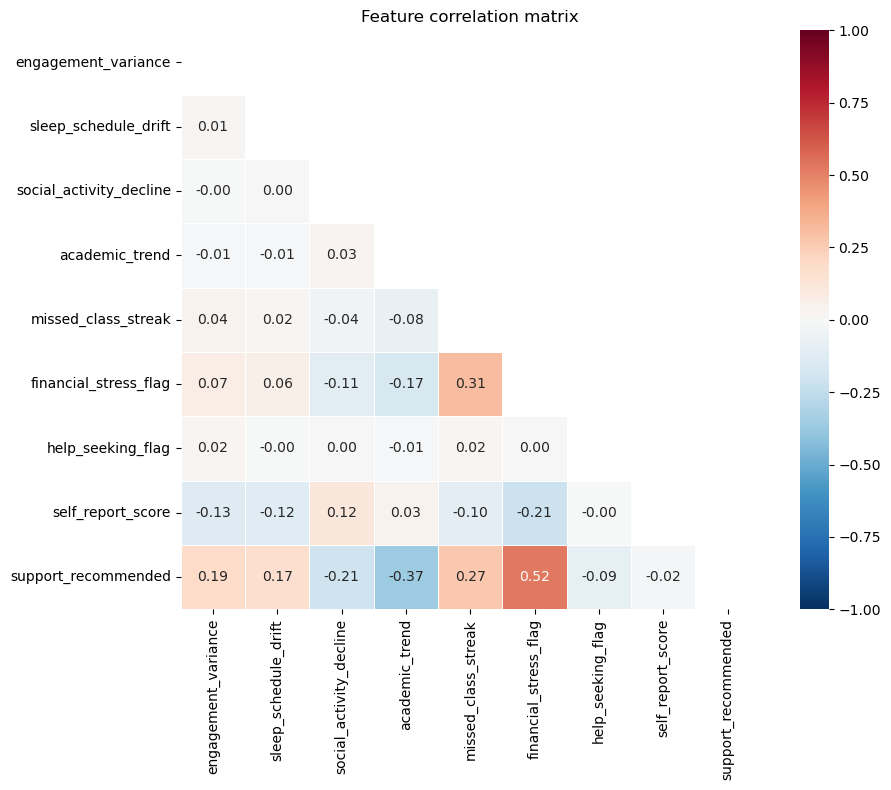

Feature correlation with label:
financial_stress_flag      0.524
academic_trend            -0.365
missed_class_streak        0.268
social_activity_decline   -0.207
engagement_variance        0.192
sleep_schedule_drift       0.170
help_seeking_flag         -0.093
self_report_score         -0.017
Name: support_recommended, dtype: float64


In [3]:
corr_cols = FEATURE_COLS + [TARGET_COL]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

# Features most correlated with label
label_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("Feature correlation with label:")
print(label_corr.round(3))

## 3. Demographic Confounds Analysis

Shows how demographic group membership correlates with behavioral features —
the realistic confounds built into the generator. Phase 5 bias audit will test
whether these confounds propagate into model predictions.

In [4]:
# Positive rate by demographic group
for demo_col in ["gender", "race_ethnicity", "first_gen", "financial_aid_status"]:
    rates = df.groupby(demo_col)[TARGET_COL].mean().sort_values(ascending=False)
    print(f"\nPositive rate by {demo_col}:")
    for k, v in rates.items():
        print(f"  {k}: {v:.3f}")
    spread = rates.max() - rates.min()
    flag = " ⚠️  > 5pp spread" if spread > 0.05 else " ✓"
    print(f"  Spread: {spread:.3f}{flag}")


Positive rate by gender:
  male: 0.184
  female: 0.178
  other_not_listed: 0.170
  non_binary: 0.166
  prefer_not_to_say: 0.133
  Spread: 0.051 ⚠️  > 5pp spread

Positive rate by race_ethnicity:
  native_american: 0.220
  prefer_not_to_say: 0.184
  black: 0.182
  white: 0.181
  multiracial: 0.178
  hispanic_latino: 0.178
  pacific_islander: 0.178
  other: 0.177
  asian: 0.166
  Spread: 0.054 ⚠️  > 5pp spread

Positive rate by first_gen:
  1: 0.207
  0: 0.164
  Spread: 0.043 ✓

Positive rate by financial_aid_status:
  both: 0.248
  pell_grant: 0.213
  loans_only: 0.180
  none: 0.107
  Spread: 0.142 ⚠️  > 5pp spread


In [5]:
# Financial stress confound
print("Financial stress rate by aid status:")
print(df.groupby("financial_aid_status")["financial_stress_flag"].mean().round(3))

print("\nEngagement variance: first-gen vs continuing-gen:")
print(df.groupby("first_gen")["engagement_variance"].describe().round(3))

print("\nMissed class streak: first-gen vs continuing-gen:")
print(df.groupby("first_gen")["missed_class_streak"].mean().round(3))

Financial stress rate by aid status:
financial_aid_status
both          0.421
loans_only    0.281
none          0.119
pell_grant    0.358
Name: financial_stress_flag, dtype: float64

Engagement variance: first-gen vs continuing-gen:
             count   mean   std    min    25%    50%    75%  max
first_gen                                                       
0          19256.0  0.366  0.16  0.078  0.242  0.345  0.470  1.0
1          10744.0  0.380  0.16  0.091  0.255  0.357  0.485  1.0

Missed class streak: first-gen vs continuing-gen:
first_gen
0    1.780
1    2.274
Name: missed_class_streak, dtype: float64


## 4. Class Imbalance Check

In [6]:
label_counts = df[TARGET_COL].value_counts()
print(f"Class distribution:\n{label_counts}")
print(f"\nImbalance ratio: {label_counts[0] / label_counts[1]:.1f}:1")
print("SMOTE will be applied to training split to balance classes before fitting.")

Class distribution:
support_recommended
0    24612
1     5388
Name: count, dtype: int64

Imbalance ratio: 4.6:1
SMOTE will be applied to training split to balance classes before fitting.


## 5. Feature Importance Preview (Mutual Information)

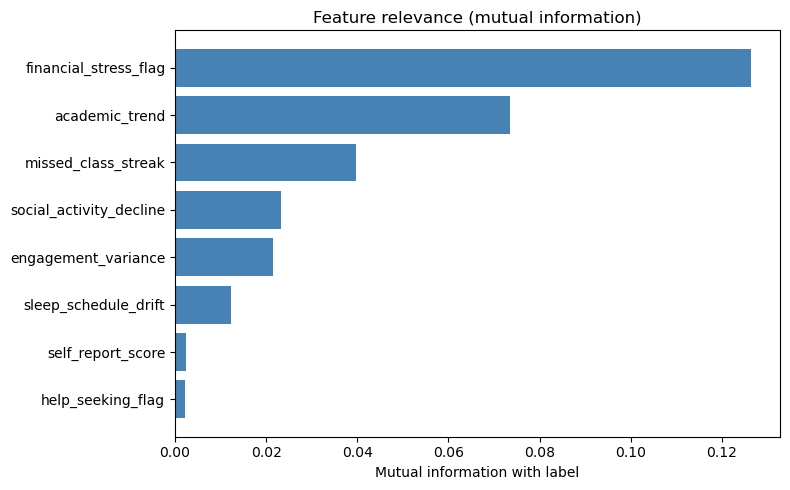

                feature  mutual_info
  financial_stress_flag     0.126457
         academic_trend     0.073489
    missed_class_streak     0.039784
social_activity_decline     0.023326
    engagement_variance     0.021406
   sleep_schedule_drift     0.012295
      self_report_score     0.002346
      help_seeking_flag     0.002087


In [7]:
from sklearn.feature_selection import mutual_info_classif

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"feature": FEATURE_COLS, "mutual_info": mi_scores})
mi_df = mi_df.sort_values("mutual_info", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mi_df["feature"], mi_df["mutual_info"], color="steelblue")
ax.set_xlabel("Mutual information with label")
ax.set_title("Feature relevance (mutual information)")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "feature_mutual_info.png", dpi=120, bbox_inches="tight")
plt.show()
print(mi_df.sort_values("mutual_info", ascending=False).to_string(index=False))